In [3]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import os
import time
import copy
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision
from sklearn.metrics import roc_auc_score, confusion_matrix, matthews_corrcoef ,accuracy_score ,precision_score , recall_score ,f1_score,classification_report
from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np



c:\Users\nice\anaconda3\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [8]:
import os
import pandas as pd
Dataset_path = r"D:\__Projects\Graduation---Project\DL\Brain_Tumor\Data"
def load_data(dataset_path):
    data =[]
    labels =[]
    types =[]
    for split in os.listdir(dataset_path):
        split_path = os.path.join(dataset_path, split)
        if os.path.isdir(split_path):
            for label in os.listdir(split_path):
                label_path = os.path.join(split_path, label)
                if os.path.isdir(label_path):
                    for image_file in os.listdir(label_path):
                        image_path = os.path.join(label_path, image_file)
                        data.append(image_path)
                        labels.append(label)
                        types.append(split)  

    return pd.DataFrame({'image_path': data,'label': labels,'type': types})
df=load_data(Dataset_path)
df

,image_path,label,type
0,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
1,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
2,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
3,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
4,D:\__Projects\Graduation---Project\DL\Brain_Tu...,glioma_tumor,Testing
...,...,...,...
3259,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training
3260,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training
3261,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training
3262,D:\__Projects\Graduation---Project\DL\Brain_Tu...,pituitary_tumor,Training


In [9]:
df.loc[df['type']=='Training', 'type']='train'
df.loc[df['type']=='Testing','type']="test"

In [10]:
df["label"].value_counts()

label
meningioma_tumor    937
glioma_tumor        926
pituitary_tumor     901
no_tumor            500
Name: count, dtype: int64

In [11]:
df.isna().sum()

image_path    0
label         0
type          0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df_train = df[df['type']=='train']
df_test = df[df['type']=='test']

label
pituitary_tumor     827
glioma_tumor        826
meningioma_tumor    822
no_tumor            395
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

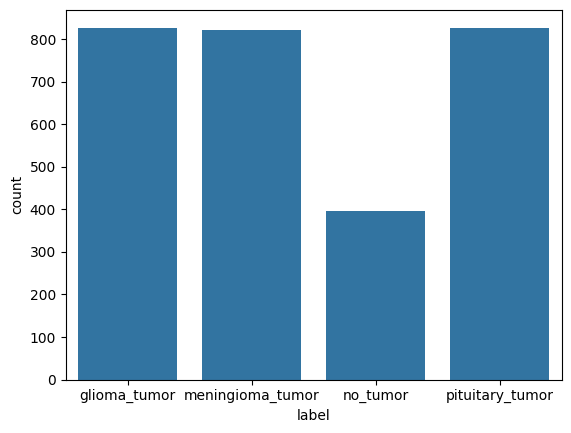

In [14]:
print(df_train['label'].value_counts())
sns.countplot(x='label', data=df_train)

label
meningioma_tumor    115
no_tumor            105
glioma_tumor        100
pituitary_tumor      74
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

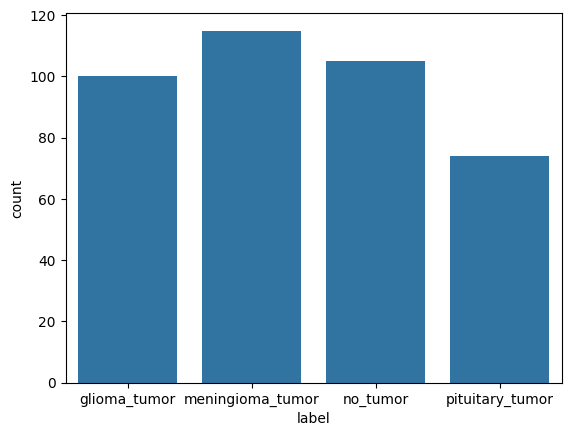

In [94]:
print(df_test['label'].value_counts())
sns.countplot(x='label', data=df_test)

In [15]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class Brain_TumorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df=df.copy()
        self.transform = transform
        self.df['label_idx']=self.df['label'].map({'meningioma_tumor': 0, 'no_tumor': 1, 'glioma_tumor': 2,"pituitary_tumor": 3}).astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return image, label

In [16]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df[df['type'] == 'train'],test_size=0.2,random_state=42,stratify=df[df['type']=="train"]['label'] )
test_df = df[df['type'] == 'test']
train_dataset= Brain_TumorDataset(train_df, transform=train_transform)
val_dataset= Brain_TumorDataset(val_df,   transform=val_transform)
test_dataset= Brain_TumorDataset(test_df,  transform=val_transform)
train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader= DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)
test_loader= DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)


In [98]:
from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# Model
# =====================
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 4)
)

model = model.to(device)

# =====================
# Class Weights (FIXED)
# =====================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# =====================
# Loss (FIXED - no overwrite)
# =====================
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# =====================
# Optimizer
# =====================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# =====================
# Training Loop
# =====================
epochs = 25

for e in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    print(f"Epoch [{e+1}/{epochs}] | Training Loss: {epoch_loss:.4f}")

Epoch [1/25] | Training Loss: 0.9696
Epoch [2/25] | Training Loss: 0.7171
Epoch [3/25] | Training Loss: 0.6672
Epoch [4/25] | Training Loss: 0.6253
Epoch [5/25] | Training Loss: 0.6016
Epoch [6/25] | Training Loss: 0.5870
Epoch [7/25] | Training Loss: 0.5389
Epoch [8/25] | Training Loss: 0.5486
Epoch [9/25] | Training Loss: 0.5395
Epoch [10/25] | Training Loss: 0.5473
Epoch [11/25] | Training Loss: 0.5284
Epoch [12/25] | Training Loss: 0.5185
Epoch [13/25] | Training Loss: 0.5075
Epoch [14/25] | Training Loss: 0.5110
Epoch [15/25] | Training Loss: 0.4933
Epoch [16/25] | Training Loss: 0.4953
Epoch [17/25] | Training Loss: 0.4990
Epoch [18/25] | Training Loss: 0.4817
Epoch [19/25] | Training Loss: 0.4833
Epoch [20/25] | Training Loss: 0.4762
Epoch [21/25] | Training Loss: 0.4619
Epoch [22/25] | Training Loss: 0.4730
Epoch [23/25] | Training Loss: 0.4526
Epoch [24/25] | Training Loss: 0.4586
Epoch [25/25] | Training Loss: 0.4644


In [99]:
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

print("ResNet18 Results:")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=['meningioma_tumor', 'no_tumor', 'glioma_tumor', 'pituitary_tumor']
))

ResNet18 Results:
Accuracy: 82.23%
Precision: 0.840 | Recall: 0.822 | F1: 0.818 | AUC: 0.938
                  precision    recall  f1-score   support

meningioma_tumor       0.77      0.94      0.85       115
        no_tumor       0.78      0.94      0.85       105
    glioma_tumor       0.88      0.65      0.75       100
 pituitary_tumor       0.98      0.70      0.82        74

        accuracy                           0.82       394
       macro avg       0.85      0.81      0.82       394
    weighted avg       0.84      0.82      0.82       394



In [111]:
torch.save(model.state_dict(), r"D:\__Projects\Graduation---Project\app\models\resnet18_brain_tumor.pth")

In [5]:
model = resnet18(weights=None)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 4)
)

model.load_state_dict(torch.load(r"D:\__Projects\Graduation---Project\app\models\resnet18_brain_tumor.pth"))
model.to(device)
model.eval()

C:\Users\nice\AppData\Local\Temp\ipykernel_23548\2384965224.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"D:\__Projects\Graduation-

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def generate(self, input_image, class_idx=None):
        self.model.eval()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output).item()

        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Gradients or activations not captured")

        grads = self.gradients
        acts = self.activations

        weights = torch.mean(grads, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * acts, dim=1).squeeze().cpu().numpy()

        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam

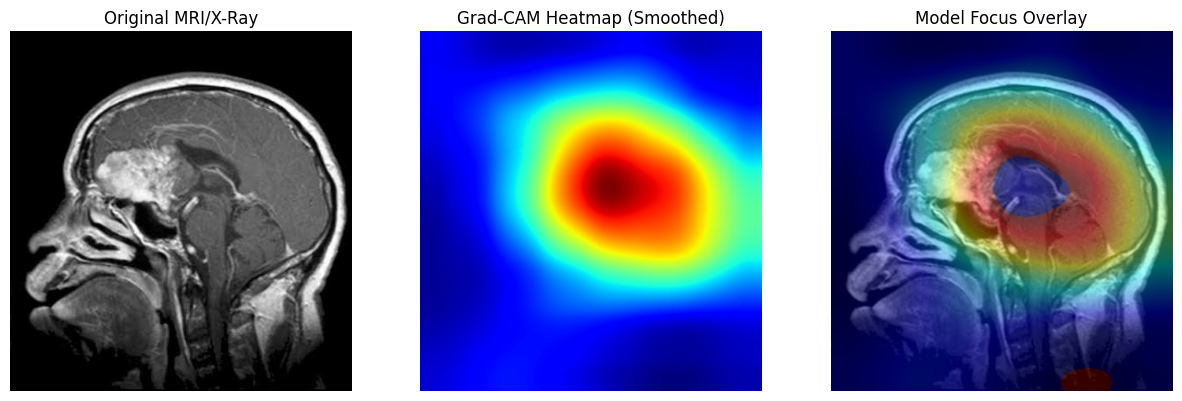

In [20]:
s= test_df.iloc[1]
img_path=s['image_path']
img = Image.open(img_path).convert('RGB')
transform= val_transform
input_tensor= transform(img).unsqueeze(0).to(device)
target_layer= model.layer4[-1] 
gradcam= GradCAM(model, target_layer)
cam= gradcam.generate(input_tensor)
# 1. نحدد الحجم الأصلي للصورة اللي دخلت للموديل (مثلاً 224x224)
# أو يفضل نستخدم حجم الصورة الأصلية قبل الـ transform لو عايز جودة أعلى
orig_width, orig_height = img.size 

# 2. نكبر الـ CAM عشان يملأ الصورة الأصلية باستخدام Interpolation ناعم
cam_resized = cv2.resize(cam, (orig_width, orig_height), interpolation=cv2.INTER_CUBIC)

# 3. تحويل الـ Heatmap لـ RGB
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# 4. دمج الـ Heatmap مع الصورة الأصلية (img_np لازم تكون بحجمها الأصلي)
img_np = np.array(img)
superimposed = cv2.addWeighted(heatmap, 0.4, img_np, 0.6, 0)

# العرض
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Original MRI/X-Ray")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap='jet')
plt.title("Grad-CAM Heatmap (Smoothed)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title("Model Focus Overlay")
plt.axis('off')
plt.show()